load dataset

In [1]:
import pandas as pd


df = pd.read_csv(
    "../data/raw/BindingDB_BindingDB_Articles.tsv",
    sep="\t",
    low_memory=False
)

print(df.shape)

(93712, 640)


find the columns

In [2]:
for col in df.columns:
    print(col)

BindingDB Reactant_set_id
Ligand SMILES
Ligand InChI
Ligand InChI Key
BindingDB MonomerID
BindingDB Ligand Name
Target Name
Target Source Organism According to Curator or DataSource
Ki (nM)
IC50 (nM)
Kd (nM)
EC50 (nM)
kon (M-1-s-1)
koff (s-1)
pH
Temp (C)
Curation/DataSource
Article DOI
BindingDB Entry DOI
PMID
PubChem AID
Patent Number
Authors
Date of publication
Date in BindingDB
Institution
Link to Ligand in BindingDB
Link to Target in BindingDB
Link to Ligand-Target Pair in BindingDB
Ligand HET ID in PDB
PDB ID(s) for Ligand-Target Complex
PubChem CID
PubChem SID
ChEBI ID of Ligand
ChEMBL ID of Ligand
DrugBank ID of Ligand
IUPHAR_GRAC ID of Ligand
KEGG ID of Ligand
ZINC ID of Ligand
Number of Protein Chains in Target (>1 implies a multichain complex)
BindingDB Target Chain Sequence 1
PDB ID(s) of Target Chain 1
UniProt (SwissProt) Recommended Name of Target Chain 1
UniProt (SwissProt) Entry Name of Target Chain 1
UniProt (SwissProt) Primary ID of Target Chain 1
UniProt (SwissProt) S

create reduced dataset

In [3]:
cols = [
    "Ligand SMILES",
    "Target Name",
    "Ki (nM)"
]

data = df[cols].copy()

remove missing values

In [4]:
data = data.dropna()

remove weird Ki values

In [5]:
mask = ~data["Ki (nM)"].astype(str).str.contains(
    "<|>|~",
    regex=True
)

data = data[mask]

convert Ki

In [6]:
data["Ki (nM)"] = (
    data["Ki (nM)"]
    .astype(float)
)

In [7]:
print(data.shape)

data.head()

(22232, 3)


,Ligand SMILES,Target Name,Ki (nM)
37,CCC(c1ccccc1)c1c(O)c2ccccc2oc1=O,Dimer of Gag-Pol polyprotein [489-587],1000.0
38,CCC(c1ccccc1)c1c(O)cc(CCc2ccccc2)oc1=O,Dimer of Gag-Pol polyprotein [489-587],500.0
39,CCC(Cc1ccccc1)c1cc(O)c(C(CC)c2ccccc2)c(=O)o1,Dimer of Gag-Pol polyprotein [489-587],38.0
40,Oc1c2CCCCCCc2oc(=O)c1C(C1CC1)c1ccccc1,Dimer of Gag-Pol polyprotein [489-587],15.0
41,CCC(Cc1ccccc1)c1cc(O)c(C(CC)c2ccccc2)c(=O)o1,Dimer of Gag-Pol polyprotein [514-612],32.0


In [8]:
data.to_csv(
    "../data/processed/bindingdb_clean.csv",
    index=False
)

In [9]:
print(data["Ki (nM)"].describe())

count    2.223200e+04
mean     7.254004e+05
std      1.980803e+07
min      6.000000e-06
25%      1.500000e+01
50%      2.000000e+02
75%      2.822500e+03
max      1.000000e+09
Name: Ki (nM), dtype: float64


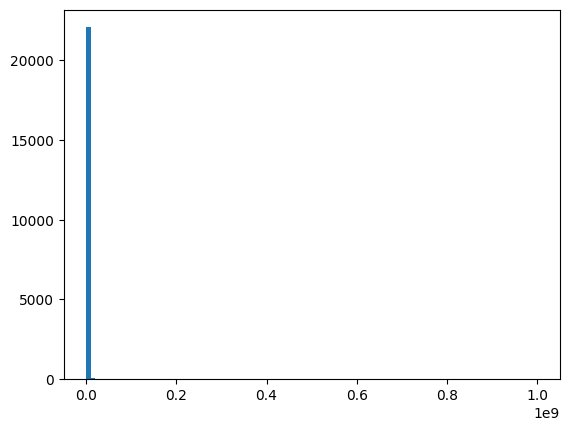

In [10]:
import matplotlib.pyplot as plt

plt.hist(
    data["Ki (nM)"],
    bins=100
)

plt.show()

In [11]:
import numpy as np

data["pKi"] = -np.log10(
    data["Ki (nM)"] * 1e-9
)

data[["Ki (nM)", "pKi"]].head()

,Ki (nM),pKi
37,1000.0,6.000000
38,500.0,6.301030
39,38.0,7.420216
40,15.0,7.823909
41,32.0,7.494850


In [12]:
data["pKi"].describe()

count    22232.000000
mean         6.656681
std          1.673141
min         -0.000000
25%          5.549367
50%          6.698970
75%          7.823909
max         14.221849
Name: pKi, dtype: float64

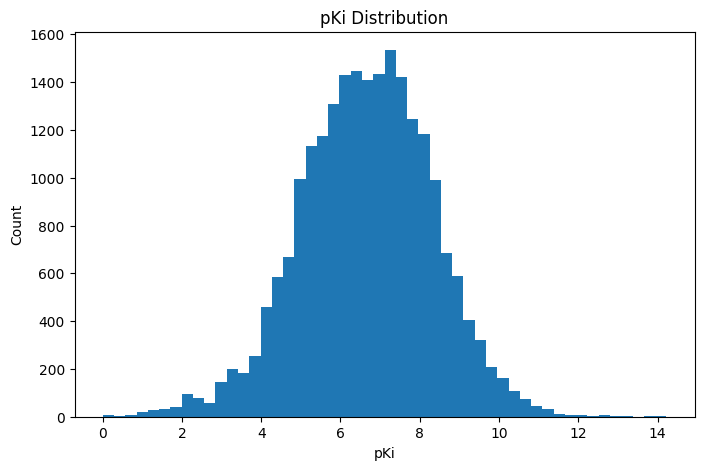

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    data["pKi"],
    bins=50
)

plt.title("pKi Distribution")
plt.xlabel("pKi")
plt.ylabel("Count")

plt.show()

In [14]:
data.to_csv(
    "../data/processed/bindingdb_clean.csv",
    index=False
)